# **HOMEWORK 1: Gradient Descent**

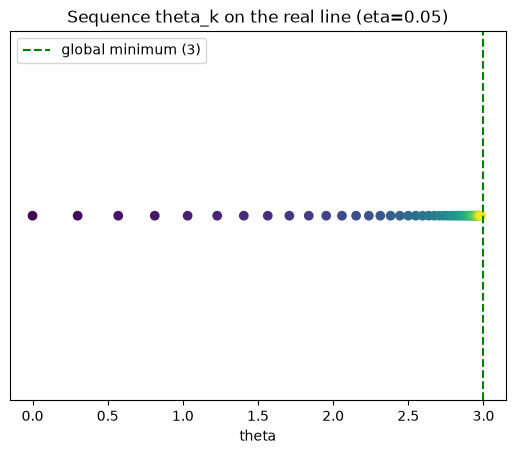

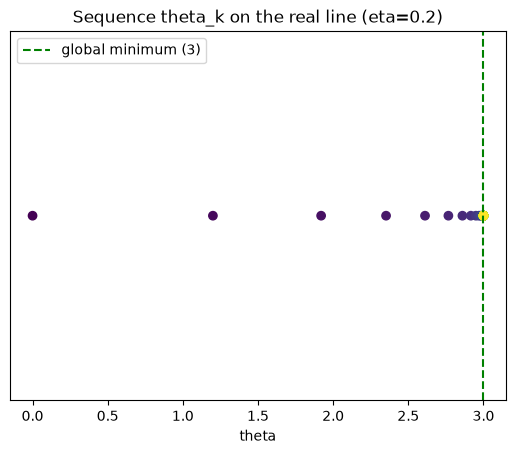

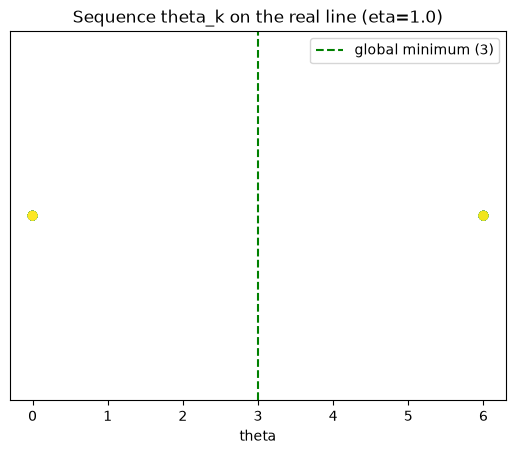

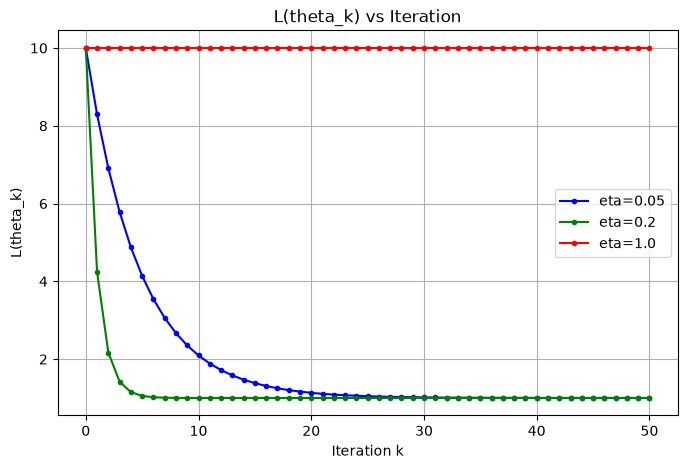

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: GD on a 1D function
loss = lambda t: (t - 3)**2 + 1
grad = lambda t: 2*(t - 3)

def gradient_descent(fn, grad_fn, start, step, n_iter):
    path = [start]
    t = start
    for _ in range(n_iter):
        t = t - step * grad_fn(t)
        path.append(t)
    return np.array(path)

t0 = 0
steps  = [0.05, 0.2, 1.0]
n_iter = 50
colors = ['blue', 'green', 'red']

for step in steps:
    pts   = gradient_descent(loss, grad, t0, step, n_iter)
    iters = np.arange(len(pts))
    plt.figure()
    plt.axvline(x=3, color='g', linestyle='--', label='global minimum (3)')
    plt.scatter(pts, np.zeros_like(pts), c=iters)
    plt.yticks([])
    plt.xlabel('theta')
    plt.title(f'Sequence theta_k on the real line (eta={step})')
    plt.legend()

plt.figure(figsize=(8, 5))
for step, c in zip(steps, colors):
    pts   = gradient_descent(loss, grad, t0, step, n_iter)
    iters = np.arange(len(pts))
    plt.plot(iters, loss(pts), marker='o', markersize=3, color=c, label=f'eta={step}')
plt.xlabel('Iteration k')
plt.ylabel('L(theta_k)')
plt.title('L(theta_k) vs Iteration')
plt.legend()
plt.grid(True)
plt.show()

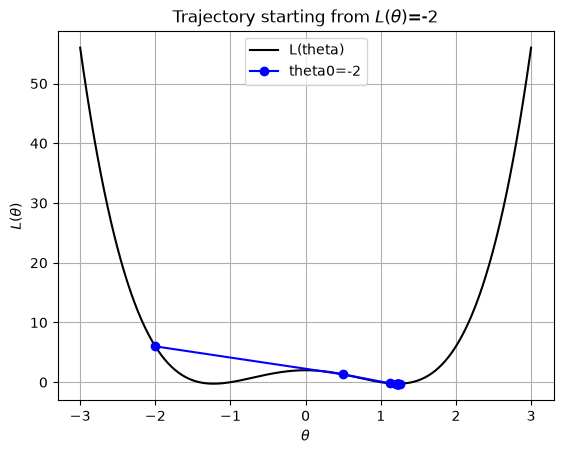

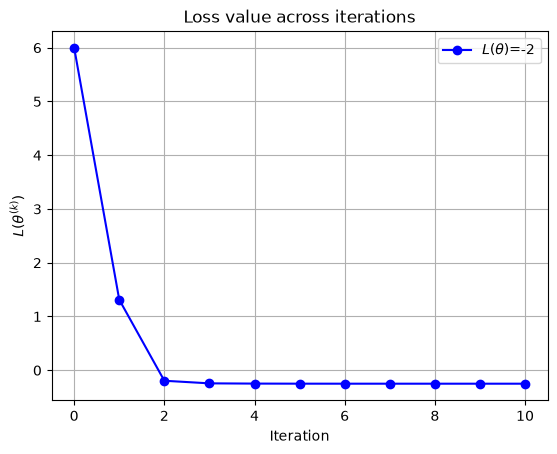

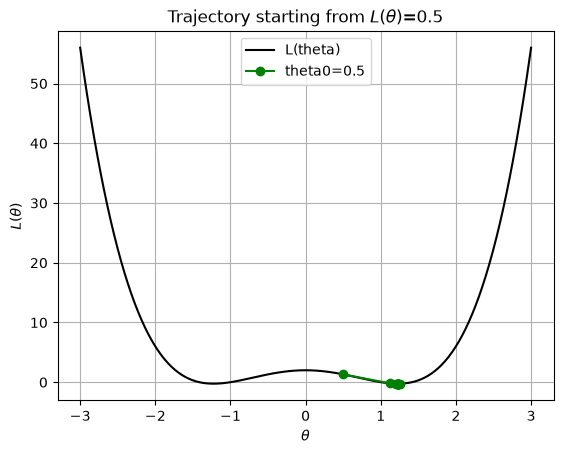

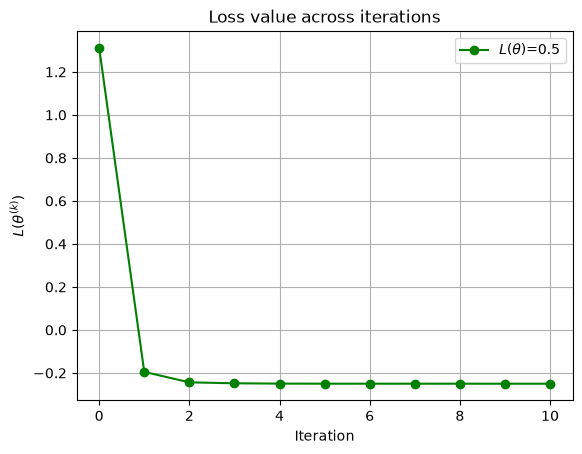

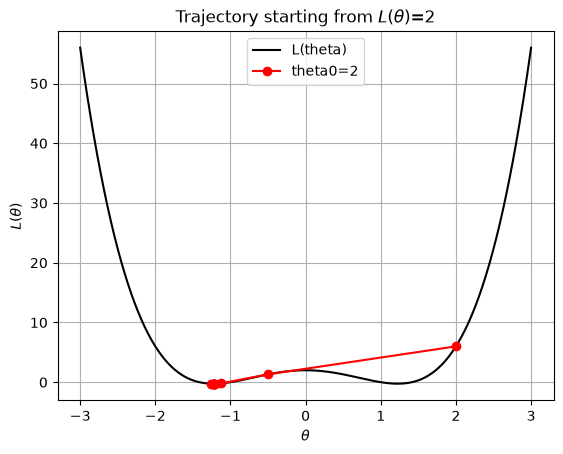

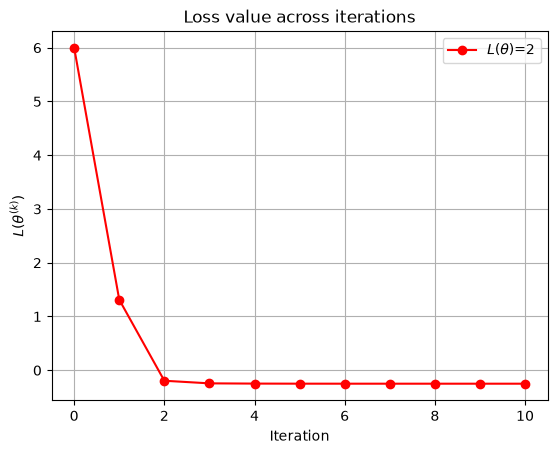

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 2: Backtracking line search
loss = lambda t: t**4 - 3*t**2 + 2
grad = lambda t: 4*t**3 - 6*t

def backtracking(fn, grad_fn, t, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_fn(t)
    g_norm2 = g * g
    while fn(t - eta * g) > fn(t) - c * eta * g_norm2:
        eta *= beta
    return eta

def gd_backtracking(fn, grad_fn, start, eta0, n_iter):
    path = [start]
    t = start
    for _ in range(n_iter):
        eta = backtracking(fn, grad_fn, t, eta0)
        t   = t - eta * grad_fn(t)
        path.append(t)
    return np.array(path)

starts = [-2, 0.5, 2]
colors = ['blue', 'green', 'red']
n_iter = 10
eta0 = 1.0
theta_grid = np.linspace(-3, 3, 400)

for start, c in zip(starts, colors):
    path = gd_backtracking(loss, grad, start, eta0, n_iter)

    plt.figure()
    plt.plot(theta_grid, loss(theta_grid), 'k-', label='L(theta)')
    plt.plot(path, loss(path), 'o-', color=c, label=f'theta0={start}')
    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$L(\theta)$')
    plt.title(fr'Trajectory starting from $L(\theta)$={start}')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(loss(path), 'o-', color=c, label=fr'$L(\theta)$={start}')
    plt.xlabel('Iteration')
    plt.ylabel(r'$L(\theta^{(k)})$')
    plt.title('Loss value across iterations')
    plt.legend()
    plt.grid(True)
    plt.show()


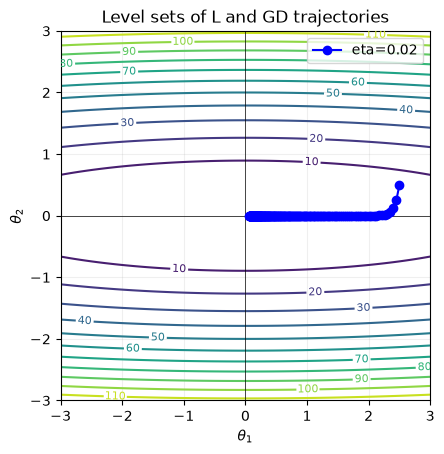

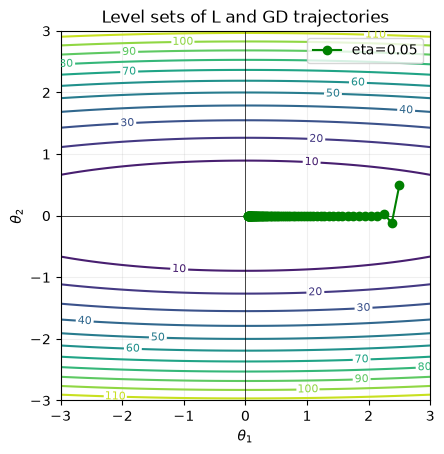

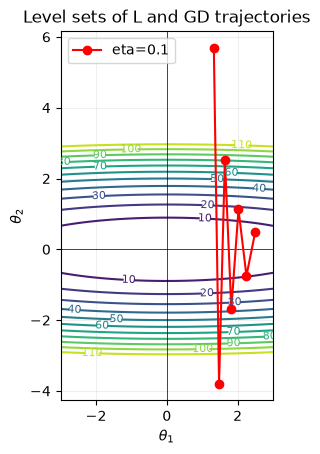

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Exercise 3: GD in 2D
A = np.diag([1.0, 25.0])
loss = lambda t: 0.5 * t @ A @ t
grad = lambda t: A @ t

def gradient_descent(fn, grad_fn, start, step, n_iter):
    path = [start.copy()]
    t = start.copy()
    for _ in range(n_iter):
        t = t - step * grad_fn(t)
        path.append(t.copy())
    return np.array(path)

def quad_levelsets(A, xlim=(-3,3), ylim=(-3,3), ngrid=400,
                   ncontours=12, title=None):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = 0.5*(A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)
    cs = plt.contour(X, Y, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.grid(alpha=0.2)

t0 = np.array([2.5, 0.5])
configs = [(0.02, 180), (0.05, 80), (0.1, 6)]
colors  = ['blue', 'green', 'red']
for (step, n_iter), c in zip(configs, colors):
    path = gradient_descent(loss, grad, t0, step, n_iter)
    plt.figure()
    quad_levelsets(A, title="Level sets of L and GD trajectories")
    plt.plot(path[:,0], path[:,1], 'o-', color=c, label=f'eta={step}')
    plt.legend()
    plt.show()


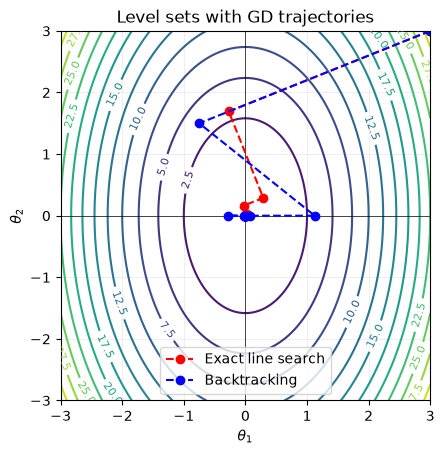

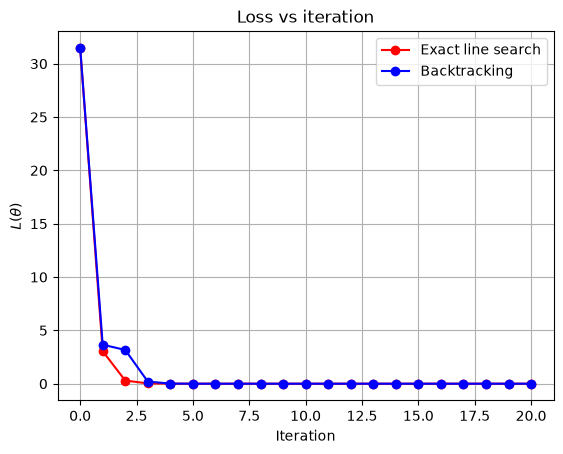

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Exercise 4: Exact line search vs backtracking
A    = np.array([[5, 0], [0, 2]], dtype=float)
loss = lambda t: 0.5 * t @ A @ t
grad = lambda t: A @ t

def gd_exact(fn, grad_fn, start, n_iter):
    path = [start.copy()]
    t    = start.copy()
    for _ in range(n_iter):
        g   = grad_fn(t)
        eta = (g @ g) / (g @ A @ g)
        t   = t - eta * g
        path.append(t.copy())
    return np.array(path)

def backtracking(fn, grad_fn, t, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_fn(t)
    g_norm2 = g @ g
    while fn(t - eta * g) > fn(t) - c * eta * g_norm2:
        eta *= beta
    return eta

def gd_backtracking(fn, grad_fn, start, eta0, n_iter):
    path = [start.copy()]
    t = start.copy()
    for _ in range(n_iter):
        eta = backtracking(fn, grad_fn, t, eta0)
        t = t - eta * grad_fn(t)
        path.append(t.copy())
    return np.array(path)

def compute_losses(fn, path):
    return np.array([fn(t) for t in path])

def quad_levelsets(A, xlim=(-3,3), ylim=(-3,3), ngrid=400,
                   ncontours=12, title=None):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = 0.5*(A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)
    cs = plt.contour(X, Y, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.grid(alpha=0.2)


t0 = np.array([3.0, 3.0])
n_iter = 20
path_exact = gd_exact(loss, grad, t0, n_iter)
path_backtracking  = gd_backtracking(loss, grad, t0, eta0=1.0, n_iter=n_iter)

plt.figure()
quad_levelsets(A, title="Level sets with GD trajectories")
plt.plot(path_exact[:,0], path_exact[:,1], 'o--', label='Exact line search', color="red")
plt.plot(path_backtracking[:,0],  path_backtracking[:,1],  'o--', label='Backtracking', color="blue")
plt.legend()
plt.show()

plt.figure()
plt.plot(compute_losses(loss, path_exact), 'o-', label='Exact line search', color="red")
plt.plot(compute_losses(loss, path_backtracking),  'o-', label='Backtracking', color="blue")
plt.xlabel("Iteration")
plt.ylabel(r"$L(\theta)$")
plt.title("Loss vs iteration")
plt.legend()
plt.grid(True)
plt.show()


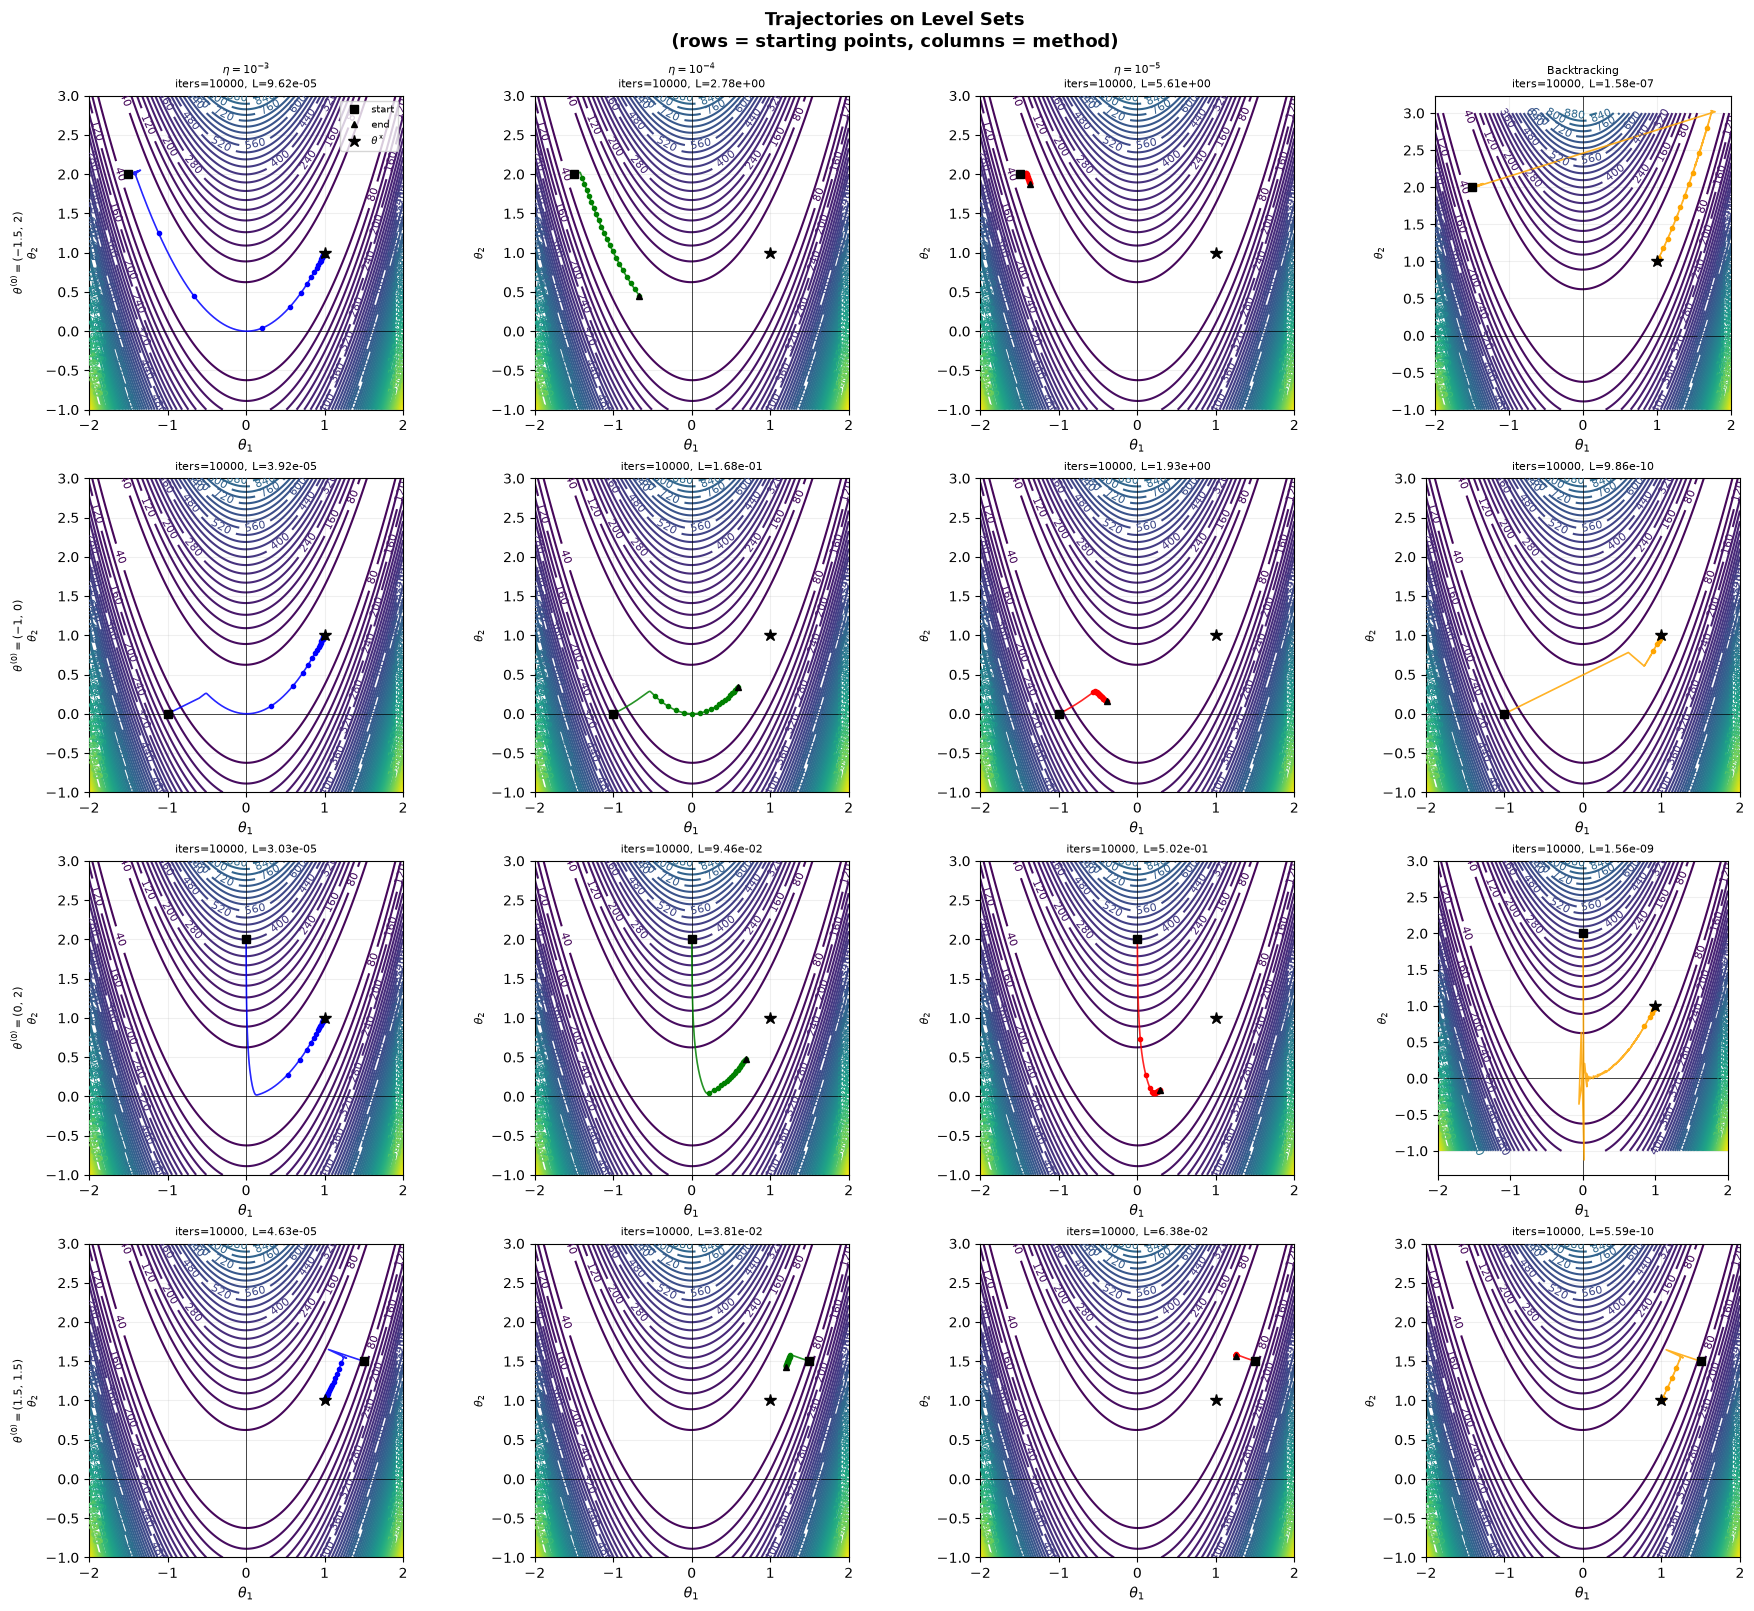

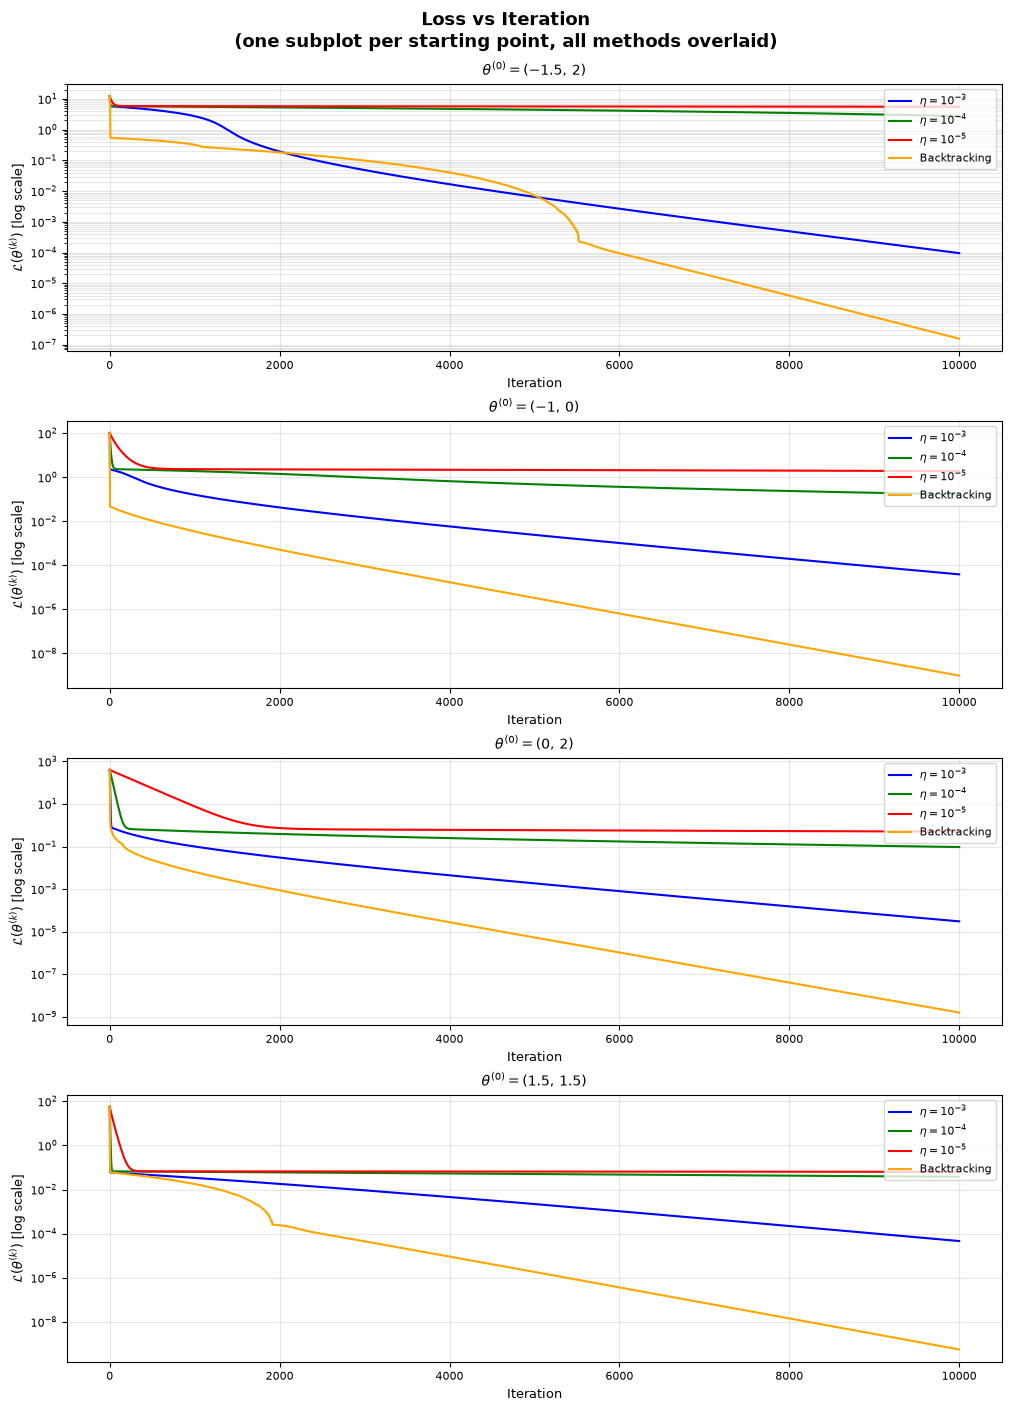


Starting point            Method              Iters       Final L  Final theta
--------------------------------------------------------------------------------
[-1.5  2. ]               $\eta=10^{-3}$      10000     9.616e-05  [0.99020202 0.98046061]
[-1.5  2. ]               $\eta=10^{-4}$      10000     2.782e+00  [-0.66593918  0.45147674]
[-1.5  2. ]               $\eta=10^{-5}$      10000     5.606e+00  [-1.3664726   1.87488363]
[-1.5  2. ]               Backtracking        10000     1.576e-07  [1.00039591 1.0007949 ]

[-1.  0.]                 $\eta=10^{-3}$      10000     3.922e-05  [0.99374283 0.98749967]
[-1.  0.]                 $\eta=10^{-4}$      10000     1.675e-01  [0.59120872 0.34750822]
[-1.  0.]                 $\eta=10^{-5}$      10000     1.935e+00  [-0.38937886  0.15839776]
[-1.  0.]                 Backtracking        10000     9.858e-10  [0.99996871 0.99993716]

[0. 2.]                   $\eta=10^{-3}$      10000     3.032e-05  [0.99449844 0.98900505]
[0. 2.]     

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

loss = lambda t: (1 - t[0])**2 + 100*(t[1] - t[0]**2)**2
grad = lambda t: np.array([
    -2*(1 - t[0]) - 400*t[0]*(t[1] - t[0]**2),
    200*(t[1] - t[0]**2)
])

def gradient_descent(fn, grad_fn, start, step, n_iter):
    path = [start.copy()]
    t = start.copy()
    for _ in range(n_iter):
        t = t - step * grad_fn(t)
        if not np.all(np.isfinite(t)):
            break
        path.append(t.copy())
    return np.array(path)

def backtracking(fn, grad_fn, t, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_fn(t)
    g_norm2 = g @ g
    while fn(t - eta * g) > fn(t) - c * eta * g_norm2:
        eta *= beta
        if eta < 1e-16:
            break
    return eta

def gd_backtracking(fn, grad_fn, start, eta0, n_iter):
    path = [start.copy()]
    t = start.copy()
    for _ in range(n_iter):
        eta = backtracking(fn, grad_fn, t, eta0)
        t   = t - eta * grad_fn(t)
        if not np.all(np.isfinite(t)):
            break
        path.append(t.copy())
    return np.array(path)

def quad_levelsets(ax, xlim=(-2,2), ylim=(-1,3), ngrid=400, ncontours=80, title=None):
    xs, ys = np.linspace(*xlim, ngrid), np.linspace(*ylim, ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = (1 - X)**2 + 100*(Y - X**2)**2
    cs = ax.contour(X, Y, Z, levels=ncontours)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.axhline(0, lw=0.5, color='k')
    ax.axvline(0, lw=0.5, color='k')
    ax.set_aspect('equal', 'box')
    if title:
        ax.set_title(title)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.grid(alpha=0.2)

init_points = [np.array(p) for p in [[-1.5, 2.0], [-1.0, 0.0], [0.0, 2.0], [1.5, 1.5]]]
init_labels = [r'$\theta^{(0)}=(-1.5,\,2)$', r'$\theta^{(0)}=(-1,\,0)$',
                 r'$\theta^{(0)}=(0,\,2)$',    r'$\theta^{(0)}=(1.5,\,1.5)$']
step_sizes = [1e-3, 1e-4, 1e-5]
method_labels = [r'$\eta=10^{-3}$', r'$\eta=10^{-4}$', r'$\eta=10^{-5}$', 'Backtracking']
colors = ['blue', 'green', 'red', 'orange']
n_iter = 10_000

# paths[i][j] = trajectory for init i, method j
paths = []
for t0 in init_points:
    row = [gradient_descent(loss, grad, t0, s, n_iter) for s in step_sizes]
    row.append(gd_backtracking(loss, grad, t0, eta0=1.0, n_iter=n_iter))
    paths.append(row)

n_inits, n_methods = len(init_points), len(method_labels)

# Figure 1: trajectory grid (n_inits rows x n_methods cols)
fig1, axes1 = plt.subplots(n_inits, n_methods,
                            figsize=(4.5*n_methods, 4.0*n_inits),
                            constrained_layout=True)
fig1.suptitle('Trajectories on Level Sets\n(rows = starting points, columns = method)',
              fontsize=13, fontweight='bold')

for i, (t0, ilbl) in enumerate(zip(init_points, init_labels)):
    for j, (mlbl, c) in enumerate(zip(method_labels, colors)):
        ax = axes1[i, j]
        path = paths[i][j]
        quad_levelsets(ax)
        ax.plot(path[:,0], path[:,1], '-', color=c, linewidth=1.2, alpha=0.85, zorder=3)
        step = max(1, len(path) // 20)
        ax.plot(path[::step,0], path[::step,1], 'o', color=c, markersize=3, zorder=4)
        ax.plot(*t0,       'ks', markersize=6, zorder=5, label='start')
        ax.plot(*path[-1], 'k^', markersize=5, zorder=5, label='end')
        ax.plot(1, 1,      'k*', markersize=9, zorder=5, label=r'$\theta^*$')
        if j == 0:
            ax.set_ylabel(ilbl + '\n' + r'$\theta_2$', fontsize=8)
        else:
            ax.set_ylabel(r'$\theta_2$', fontsize=8)
        if i == 0 and j == 0:
            ax.legend(fontsize=7, loc='upper right')
        subtitle = (f'{mlbl}\n' if i == 0 else '') + f'iters={len(path)-1}, L={loss(path[-1]):.2e}'
        ax.set_title(subtitle, fontsize=8)

plt.show()

# Figure 2: loss curves (n_inits rows, all methods overlaid)
fig2, axes2 = plt.subplots(n_inits, 1, figsize=(10, 3.5*n_inits), constrained_layout=True)
fig2.suptitle('Loss vs Iteration\n(one subplot per starting point, all methods overlaid)',
              fontsize=13, fontweight='bold')

for i, (t0, ilbl) in enumerate(zip(init_points, init_labels)):
    ax = axes2[i]
    for j, (mlbl, c) in enumerate(zip(method_labels, colors)):
        ax.semilogy([loss(t) for t in paths[i][j]], '-', color=c, linewidth=1.5, label=mlbl)
    ax.set_title(ilbl, fontsize=10)
    ax.set_xlabel('Iteration', fontsize=9)
    ax.set_ylabel(r'$\mathcal{L}(\theta^{(k)})$ [log scale]', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)
    ax.tick_params(labelsize=8)

plt.show()

# Numerical summary
print(f"\n{'Starting point':<25} {'Method':<18} {'Iters':>6}  {'Final L':>12}  Final theta")
print('-' * 80)
for i, t0 in enumerate(init_points):
    for j, mlbl in enumerate(method_labels):
        p = paths[i][j]
        print(f"{str(t0):<25} {mlbl:<18} {len(p)-1:>6}  {loss(p[-1]):>12.3e}  {p[-1]}")
    print()
